# RREA - Entity Alignment on DBP15K

> **Relational Reflection Entity Alignment**
> Xin Mao, Wenting Wang, Yuanbin Wu, Man Lan (*CIKM 2020*)
> Source: https://dl.acm.org/doi/10.1145/3340531.3411894

A **self-contained** notebook (it imports nothing from an external package): the whole engine
is defined in the cells below. The same implementation is available in the `code/` package
(`code/src/models/rrea.py`, class `RREATrainer` in `code/src/trainer.py`).

## The RREA idea
RREA is the successor of MRAEA. Its key idea is the **relational reflection** operator: when a
node aggregates a neighbour connected by a relation, the neighbour vector is *reflected* across
the hyperplane orthogonal to the (unit) relation vector. This is a Householder reflection that
preserves norm and orthogonality. The model uses semi-supervised bi-directional iterative
bootstrapping with the CSLS metric between turns.

## Results (DBP15K zh_en, 30% seed)
| | Hit@1 | Hit@5 | Hit@10 | MRR |
|---|---:|---:|---:|---:|
| **This notebook** | ~0.76-0.80 | - | - | - |
| RREA (paper, semi) | 0.801 | - | 0.923 | 0.846 |

## Metrics: **MRR, Hit@1, Hit@5, Hit@10** (+ CSLS).

---
## 1. Environment, imports and style

In [22]:
import os, sys, csv, time, random, logging
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm          # plain terminal tqdm (not the notebook widget)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2024
set_seed(SEED)
torch.backends.cudnn.benchmark = True

Project root : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k
PyTorch      : 2.5.1+cu121
CUDA         : True | NVIDIA GeForce RTX 3090


### 1.1 Modern dark theme (identical to `code/src/utils/plotting.py`)

In [23]:
"""Modern dark-theme plotting helpers.

A single :func:`set_modern_dark_style` configures Matplotlib with a clean,
GitHub-dark-inspired palette so every figure (training curves, EDA, metrics)
shares a consistent, modern look. The plotting functions below are used by the
trainer and can be reused from the notebook.
"""


# GitHub-dark-inspired palette
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#21262d"
EDGE = "#30363d"
FG = "#c9d1d9"
TITLE = "#e6edf3"
MUTED = "#8b949e"
CYCLE = ["#58a6ff", "#3fb950", "#f778ba", "#ffa657", "#a371f7", "#56d4dd", "#e3b341"]


def set_modern_dark_style():
    """Apply the modern dark theme globally (idempotent)."""
    mpl.rcParams.update({
        "figure.facecolor": BG,
        "figure.edgecolor": BG,
        "savefig.facecolor": BG,
        "savefig.edgecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": EDGE,
        "axes.labelcolor": FG,
        "axes.titlecolor": TITLE,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.linewidth": 1.0,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": FG,
        "legend.facecolor": PANEL,
        "legend.edgecolor": EDGE,
        "legend.framealpha": 0.9,
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "lines.solid_capstyle": "round",
        "font.size": 11,
        "figure.dpi": 120,
        "axes.prop_cycle": mpl.cycler(color=CYCLE),
    })


def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent spine/tick styling to an Axes."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
    return ax


def plot_loss_curves(loss_hist, ax=None, keys=("loss", "kge", "align", "pseudo")):
    """Plot per-epoch loss components from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in loss_hist]
    labels = {"loss": "total", "kge": "kge (TransE)",
              "align": "align (seed)", "pseudo": "align (pseudo)"}
    for key in keys:
        ax.plot(ep, [h.get(key, 0.0) for h in loss_hist], label=labels.get(key, key))
    ax.legend()
    return style_axes(ax, "Training loss", "epoch", "loss")


def plot_metric_curves(metric_hist, ax=None):
    """Plot per-eval metric history from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in metric_hist]
    for key in [k for k in metric_hist[0] if k != "epoch"]:
        ax.plot(ep, [h[key] for h in metric_hist], marker="o", label=key)
    ax.set_ylim(0, 1)
    ax.legend()
    return style_axes(ax, "Test metrics (avg direction)", "epoch", "score")

set_modern_dark_style()
print('Dark theme applique.')

Dark theme applique.


---
## 2. Configuration (YAML) and logging
Driven by **`configs/rrea_dbp15k.yaml`**. Code identical to `code/src/utils/config.py` and `logger.py`.

In [24]:
"""Configuration loading and run-directory bootstrap.

The whole experiment is driven by a single YAML file (see ``configs/``).
This module:
  * loads that YAML into a dotted-access namespace (``cfg.train.lr`` etc.),
  * creates a timestamped *run directory* under ``logging.output_dir``,
  * dumps the resolved config back to disk for reproducibility.

The logger is created separately by :mod:`src.utils.logger`.
"""




class Cfg(dict):
    """A ``dict`` that also supports attribute access, recursively.

    ``cfg.train.lr`` is equivalent to ``cfg["train"]["lr"]``. This keeps the
    code readable while still being a plain dict underneath (so it serialises
    straight back to YAML/JSON).
    """

    def __init__(self, d: dict | None = None):
        super().__init__()
        for k, v in (d or {}).items():
            self[k] = Cfg(v) if isinstance(v, dict) else v

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError as e:
            raise AttributeError(name) from e

    def __setattr__(self, name, value):
        self[name] = Cfg(value) if isinstance(value, dict) and not isinstance(value, Cfg) else value

    def to_plain(self):
        """Convert back to nested plain dicts (for YAML/JSON dumping)."""
        return {k: (v.to_plain() if isinstance(v, Cfg) else v) for k, v in self.items()}


def load_config(path: str | Path, project_root: str | Path | None = None) -> Cfg:
    """Load a YAML config file into a :class:`Cfg` namespace.

    ``project_root`` (defaults to the parent of ``configs/``) is recorded so
    relative data/output paths can be resolved consistently regardless of the
    current working directory.
    """
    path = Path(path).resolve()
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    cfg = Cfg(raw)
    root = Path(project_root).resolve() if project_root else path.parent.parent
    cfg._project_root = str(root)
    cfg._config_path = str(path)
    return cfg


def make_run_dir(cfg: Cfg) -> Path:
    """Create (and return) the timestamped run directory for this experiment.

    Layout::

        <output_dir>/<experiment.name>_<YYYYmmdd-HHMMSS>/
            training.txt          (full training log)
            config_used.yaml      (snapshot of the resolved config)
            model.pt / model_best.pt
            embeddings.pt
            metrics.csv / loss.csv
            *.png                 (loss & metric curves)
    """
    root = Path(cfg._project_root)
    out = root / cfg.logging.output_dir
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = out / f"{cfg.experiment.name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cfg._run_dir = str(run_dir)

    # snapshot the exact config used for this run
    with open(run_dir / cfg.logging.config_dump, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg.to_plain(), f, sort_keys=False, allow_unicode=True)
    return run_dir

In [25]:
"""Logging setup: write simultaneously to the console and to ``training.txt``."""




def get_logger(cfg: Cfg, run_dir: Path) -> logging.Logger:
    """Return a logger writing to both stdout and ``training.txt``.

    Re-callable safely (handlers are reset) so re-running the setup does not
    duplicate every log line.
    """
    logger = logging.getLogger(cfg.experiment.name)
    logger.setLevel(getattr(logging, cfg.logging.log_level.upper(), logging.INFO))
    logger.handlers.clear()
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

    fh = logging.FileHandler(run_dir / cfg.logging.log_file, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

In [26]:
cfg = load_config(PROJECT_ROOT / "configs" / "rrea_dbp15k.yaml", project_root=PROJECT_ROOT)
cfg.experiment.seed = SEED
cfg.experiment.name = f"rrea_{cfg.data.lang}_{cfg.data.fold}"

run_dir = make_run_dir(cfg)
logger = get_logger(cfg, run_dir)
device = torch.device(cfg.experiment.device if torch.cuda.is_available() else "cpu")
logger.info(f"Run dir : {run_dir}")
logger.info(f"Device  : {device}")
print(yaml.safe_dump(cfg.to_plain(), sort_keys=False, allow_unicode=True))

01:49:54 | INFO    | Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/rrea_zh_en_0_3_20260602-014954
01:49:54 | INFO    | Device  : cuda
experiment:
  name: rrea_zh_en_0_3
  model: rrea
  seed: 2024
  device: cuda
data:
  root: Data/dbp15k
  lang: zh_en
  fold: '0_3'
  use_mtranse_format: true
model:
  node_hidden: 100
  depth: 2
  attn_heads: 1
  dropout: 0.3
train:
  turns: 5
  epoch_per_turn: 1200
  lr: 0.005
  optimizer: rmsprop
  weight_decay: 0.0
  gamma: 3.0
  csls_k: 10
eval:
  every: 300
  hits_at:
  - 1
  - 5
  - 10
  metric: csls
  csls_k: 10
  eval_chunk: 1024
  direction: both
logging:
  output_dir: experiments
  log_file: training.txt
  config_dump: config_used.yaml
  save_best: true
  save_last: true
  checkpoint_name: model.pt
  embeddings_name: embeddings.pt
  metrics_csv: metrics.csv
  loss_csv: loss.csv
  plots:
    loss_curve: loss_curve.png
    metrics_curve: metrics_curve.png
  log_level: INFO
_project_root: /usr/users/pgxlod_ea_internshi

---
## 3. DBP15K data and RREA graph
JAPE/MTransE format (disjoint contiguous ids). Code identical to `code/src/data.py`.
RREA reuses MRAEA's graph builder (`build_mraea_graph`).

In [27]:
"""DBP15K data loading + neighbourhood construction for NAEA.

Data layout (the clean JAPE / MTransE split we use, ``<lang>/mtranse/<fold>/``):

    ent_ids_1 / ent_ids_2 : "<id>\\t<uri>"   entities of KG1 (e.g. zh) / KG2 (en)
    rel_ids_1 / rel_ids_2 : "<id>\\t<uri>"   relations of KG1 / KG2
    triples_1 / triples_2 : "<h>\\t<r>\\t<t>"
    sup_pairs             : "<e1>\\t<e2>"    seed (training) alignments  (30% for 0_3)
    ref_pairs             : "<e1>\\t<e2>"    test alignments             (70% for 0_3)

Crucially, in this split the entity ids of KG1 and KG2 are **disjoint** and form
a single contiguous range ``0 .. num_entities-1``; likewise relation ids. That
lets us use one shared embedding table and index it directly.
"""




# --------------------------------------------------------------------------- #
#  Raw file readers
# --------------------------------------------------------------------------- #
def _read_id_uri(path: Path) -> dict[int, str]:
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                d[int(parts[0])] = parts[1]
    return d


def _read_triples(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                rows.append((int(p[0]), int(p[1]), int(p[2])))
    return np.asarray(rows, dtype=np.int64)


def _read_pairs(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 2:
                rows.append((int(p[0]), int(p[1])))
    return np.asarray(rows, dtype=np.int64)


# --------------------------------------------------------------------------- #
#  Container
# --------------------------------------------------------------------------- #
@dataclass
class DBP15K:
    """Everything the model/trainer needs, as numpy arrays + lookup dicts."""

    lang: str
    fold: str
    ent_uri: dict[int, str]            # global entity id -> uri
    rel_uri: dict[int, str]            # global relation id -> uri
    kg1_ents: np.ndarray               # entity ids belonging to KG1
    kg2_ents: np.ndarray               # entity ids belonging to KG2
    triples1: np.ndarray               # (M1, 3)  KG1 triples
    triples2: np.ndarray               # (M2, 3)  KG2 triples
    train_pairs: np.ndarray            # (S, 2)   seed alignments
    test_pairs: np.ndarray             # (T, 2)   test alignments
    num_entities: int = field(init=False)
    num_relations: int = field(init=False)

    def __post_init__(self):
        self.num_entities = int(max(self.ent_uri) + 1)
        self.num_relations = int(max(self.rel_uri) + 1)

    @property
    def triples(self) -> np.ndarray:
        return np.concatenate([self.triples1, self.triples2], axis=0)

    def summary(self) -> dict:
        return {
            "lang": self.lang,
            "fold": self.fold,
            "num_entities": self.num_entities,
            "num_relations": self.num_relations,
            "|KG1 ents|": len(self.kg1_ents),
            "|KG2 ents|": len(self.kg2_ents),
            "|KG1 triples|": len(self.triples1),
            "|KG2 triples|": len(self.triples2),
            "train_pairs": len(self.train_pairs),
            "test_pairs": len(self.test_pairs),
        }


def load_dbp15k(root: str | Path, lang: str, fold: str, use_mtranse: bool = True) -> DBP15K:
    base = Path(root) / lang / "mtranse" / fold if use_mtranse else Path(root) / lang / fold

    ent1 = _read_id_uri(base / "ent_ids_1")
    ent2 = _read_id_uri(base / "ent_ids_2")
    rel1 = _read_id_uri(base / "rel_ids_1")
    rel2 = _read_id_uri(base / "rel_ids_2")

    ent_uri = {**ent1, **ent2}
    rel_uri = {**rel1, **rel2}

    triples1 = _read_triples(base / "triples_1")
    triples2 = _read_triples(base / "triples_2")

    pair_train = "sup_pairs" if use_mtranse else "sup_ent_ids"
    pair_test = "ref_pairs" if use_mtranse else "ref_ent_ids"
    train_pairs = _read_pairs(base / pair_train)
    test_pairs = _read_pairs(base / pair_test)

    return DBP15K(
        lang=lang,
        fold=fold,
        ent_uri=ent_uri,
        rel_uri=rel_uri,
        kg1_ents=np.asarray(sorted(ent1), dtype=np.int64),
        kg2_ents=np.asarray(sorted(ent2), dtype=np.int64),
        triples1=triples1,
        triples2=triples2,
        train_pairs=train_pairs,
        test_pairs=test_pairs,
    )


# --------------------------------------------------------------------------- #
#  Neighbourhood construction
# --------------------------------------------------------------------------- #
def build_neighbors(data: DBP15K, max_neighbors: int, seed: int = 0):
    """Build padded neighbour tensors for the attention aggregator.

    For every entity ``e`` we collect its neighbours from all triples it
    participates in. A neighbour is a *(relation, entity, direction)* triplet:

      * out-edge ``(e, r, t)``  ->  neighbour ``t`` via ``r``, sign = -1
        (TransE: ``e ~= t - r``, so the message that reconstructs ``e`` is ``t - r``)
      * in-edge  ``(h, r, e)``  ->  neighbour ``h`` via ``r``, sign = +1
        (TransE: ``e ~= h + r``, message ``h + r``)

    Entities with more than ``max_neighbors`` neighbours are randomly
    sub-sampled; entities with fewer are zero-padded and masked.

    Returns four ``LongTensor``/``Tensor``/``BoolTensor`` of shape
    ``(num_entities, max_neighbors)``: ``(neigh_ent, neigh_rel, neigh_sign, mask)``.
    """
    rng = random.Random(seed)
    N = data.num_entities
    adj: list[list[tuple[int, int, int]]] = [[] for _ in range(N)]

    for arr in (data.triples1, data.triples2):
        for h, r, t in arr:
            adj[h].append((int(r), int(t), -1))   # out-edge:  e=h, message t - r
            adj[t].append((int(r), int(h), +1))   # in-edge:   e=t, message h + r

    K = max_neighbors
    neigh_ent = np.zeros((N, K), dtype=np.int64)
    neigh_rel = np.zeros((N, K), dtype=np.int64)
    neigh_sign = np.zeros((N, K), dtype=np.float32)
    mask = np.zeros((N, K), dtype=bool)

    for e in range(N):
        nbrs = adj[e]
        if len(nbrs) > K:
            nbrs = rng.sample(nbrs, K)
        for j, (r, ne, s) in enumerate(nbrs):
            neigh_rel[e, j] = r
            neigh_ent[e, j] = ne
            neigh_sign[e, j] = s
            mask[e, j] = True

    return (
        torch.from_numpy(neigh_ent),
        torch.from_numpy(neigh_rel),
        torch.from_numpy(neigh_sign),
        torch.from_numpy(mask),
    )


# --------------------------------------------------------------------------- #
#  Negative sampling helpers
# --------------------------------------------------------------------------- #
class TripleSampler:
    """Mini-batch iterator over triples with per-KG corrupted negatives.

    Negatives are produced by replacing the head *or* the tail with a uniformly
    random entity **from the same KG** (cross-KG corruptions would be trivial
    negatives and pollute the signal).
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        t1 = torch.from_numpy(data.triples1)
        t2 = torch.from_numpy(data.triples2)
        kg = torch.cat([torch.zeros(len(t1), dtype=torch.long),
                        torch.ones(len(t2), dtype=torch.long)])
        self.triples = torch.cat([t1, t2], 0).to(device)        # (M,3)
        self.kg = kg.to(device)                                  # (M,)
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, kg_flags: torch.Tensor) -> torch.Tensor:
        """A random entity from the same KG as each row of ``kg_flags``."""
        n = kg_flags.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg_flags == 0, r1, r2)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                              # (B,3)
            kg = self.kg[idx]                                    # (B,)
            B = pos.shape[0]
            # repeat for `neg` corruptions
            pos_r = pos.repeat(self.neg, 1)                      # (B*neg,3)
            kg_r = kg.repeat(self.neg)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * self.neg, device=self.device) < 0.5
            rnd = self._rand_same_kg(kg_r)
            neg[:, 0] = torch.where(corrupt_head, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rnd, neg[:, 2])
            yield pos, neg, kg


class AlignSampler:
    """Mini-batch iterator over alignment pairs with corrupted negatives.

    For a positive pair ``(e1, e2)`` we corrupt the right side (a KG2 entity)
    and the left side (a KG1 entity) to obtain negatives in both alignment
    directions. ``set_pairs`` lets the trainer inject bootstrapped pseudo-pairs.

    **Hard (nearest-neighbour) negatives.** If ``set_hard_negatives`` has been
    called, negatives are drawn from each pair's pre-computed nearest cross-KG
    candidates (the *confusable* entities) instead of uniformly at random - the
    epsilon-truncated negative sampling of BootEA/NAEA, which sharpens Hit@1. Any
    candidate that equals the gold target is replaced by a random one.
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)
        self.hard_r = None          # (S, C) nearest KG2 candidates per pair (corrupt right)
        self.hard_l = None          # (S, C) nearest KG1 candidates per pair (corrupt left)
        self.set_pairs(data.train_pairs)

    def set_pairs(self, pairs):
        if isinstance(pairs, np.ndarray):
            pairs = torch.from_numpy(pairs)
        self.pairs = pairs.to(self.device).long()
        self.hard_r = self.hard_l = None    # invalidate stale hard-negative tables

    def set_hard_negatives(self, hard_r, hard_l):
        """``hard_r``/``hard_l``: (S, C) LongTensors aligned with ``self.pairs``."""
        self.hard_r = hard_r.to(self.device)
        self.hard_l = hard_l.to(self.device)

    def __len__(self):
        return len(self.pairs)

    def _sample_hard(self, table, rows, n, gold):
        """Pick ``n`` candidates per row from ``table[rows]``, avoiding ``gold``."""
        cand = table[rows]                                       # (B, C)
        C = cand.shape[1]
        sel = torch.randint(C, (cand.shape[0], n), device=self.device)
        out = torch.gather(cand, 1, sel).reshape(-1)            # (B*n,)
        # replace any accidental gold hit with a random entity from the same KG
        pool = self.kg2_ents if table is self.hard_r else self.kg1_ents
        clash = out == gold
        if clash.any():
            out[clash] = pool[torch.randint(len(pool), (int(clash.sum()),), device=self.device)]
        return out

    def batches(self, batch_size: int, shuffle: bool = True):
        S = len(self.pairs)
        order = torch.randperm(S, device=self.device) if shuffle else torch.arange(S, device=self.device)
        for s in range(0, S, batch_size):
            idx = order[s:s + batch_size]
            pos = self.pairs[idx]                                # (B,2)
            B = pos.shape[0]
            n = self.neg
            e1 = pos[:, 0].repeat_interleave(n)
            e2 = pos[:, 1].repeat_interleave(n)
            if self.hard_r is not None and self.hard_l is not None:
                neg_r = self._sample_hard(self.hard_r, idx, n, e2)
                neg_l = self._sample_hard(self.hard_l, idx, n, e1)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (B * n,), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (B * n,), device=self.device)]
            yield pos, (e1, e2, neg_l, neg_r)


# =========================================================================== #
#  BootEA-specific helpers : alignment-by-swapping + dynamic triple sampling
# =========================================================================== #
def kg_of_entity(data: "DBP15K") -> np.ndarray:
    """Return an array ``kg[e] in {0, 1}`` giving the KG each entity belongs to."""
    kg = np.zeros(data.num_entities, dtype=np.int64)
    kg[data.kg2_ents] = 1
    return kg


class Swapper:
    """Generate BootEA *aligned triples* by swapping labelled entities.

    For a labelled pair ``(a, b)`` we substitute ``b`` for ``a`` in each of
    ``a``'s triples and vice-versa, e.g. ``(a, r, t) -> (b, r, t)``. The swapped
    entities then share relational contexts, which pulls their embeddings
    together - BootEA's core alignment mechanism.

    Per-entity triple lists are precomputed once; :meth:`generate` is then cheap
    enough to be re-run every bootstrapping round on the (growing) labelled set.
    """

    def __init__(self, data: "DBP15K"):
        triples = np.concatenate([data.triples1, data.triples2], axis=0)
        self.triples = triples
        n = data.num_entities
        self.as_head = [[] for _ in range(n)]
        self.as_tail = [[] for _ in range(n)]
        for i, (h, _r, t) in enumerate(triples):
            self.as_head[int(h)].append(i)
            self.as_tail[int(t)].append(i)

    def generate(self, labeled_pairs, cap_per_role: int = 100) -> np.ndarray:
        """Return an ``(K, 3)`` array of swapped (h, r, t) triples for the pairs."""
        T = self.triples
        out = []
        for a, b in labeled_pairs:
            a, b = int(a), int(b)
            for src, dst in ((a, b), (b, a)):          # dst takes src's place
                for ti in self.as_head[src][:cap_per_role]:
                    out.append((dst, T[ti, 1], T[ti, 2]))
                for ti in self.as_tail[src][:cap_per_role]:
                    out.append((T[ti, 0], T[ti, 1], dst))
        if not out:
            return np.empty((0, 3), dtype=np.int64)
        return np.asarray(out, dtype=np.int64)


class DynamicTripleSampler:
    """Mini-batch sampler over a *mutable* set of triples (BootEA / AlignE).

    Unlike :class:`TripleSampler` (which fixes the per-KG split), this sampler
    determines each corrupted entity's KG from a global ``kg_of_ent`` array, so
    it correctly handles **swapped** triples whose head and tail may live in
    different KGs. Negatives are uniform within the corrupted position's KG, or
    **epsilon-truncated** (drawn from that entity's nearest same-KG neighbours) when a
    candidate table has been provided via :meth:`set_candidates`.
    """

    def __init__(self, device, kg_of_ent: np.ndarray, kg1_ents, kg2_ents, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg_of_ent = torch.as_tensor(kg_of_ent, device=device).long()
        self.kg1_ents = torch.as_tensor(kg1_ents, device=device).long()
        self.kg2_ents = torch.as_tensor(kg2_ents, device=device).long()
        self.cand = None            # (N, C) nearest same-KG neighbours, optional
        self.triples = torch.empty((0, 3), dtype=torch.long, device=device)

    def set_triples(self, triples):
        if isinstance(triples, np.ndarray):
            triples = torch.from_numpy(triples)
        self.triples = triples.to(self.device).long()

    def set_candidates(self, cand):
        """``cand`` : (N, C) LongTensor of nearest same-KG neighbours per entity."""
        self.cand = cand.to(self.device) if cand is not None else None

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, ent_ids):
        kg = self.kg_of_ent[ent_ids]
        n = ent_ids.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg == 0, r1, r2)

    def _trunc_same_kg(self, ent_ids):
        """epsilon-truncated: a random one of each entity's nearest same-KG neighbours."""
        cand = self.cand[ent_ids]                              # (n, C)
        sel = torch.randint(cand.shape[1], (cand.shape[0], 1), device=self.device)
        return torch.gather(cand, 1, sel).squeeze(1)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                            # (B,3)
            B = pos.shape[0]
            n = self.neg
            pos_r = pos.repeat(n, 1)                           # (B*n,3)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * n, device=self.device) < 0.5
            # entity currently occupying the position we corrupt
            orig = torch.where(corrupt_head, pos_r[:, 0], pos_r[:, 2])
            repl = self._trunc_same_kg(orig) if self.cand is not None else self._rand_same_kg(orig)
            neg[:, 0] = torch.where(corrupt_head, repl, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, repl, neg[:, 2])
            yield pos, neg


# =========================================================================== #
#  AliNet-specific helpers : 1-hop normalised adjacency + capped 2-hop edges
# =========================================================================== #
def build_alinet_graph(data: "DBP15K", max_two_hop: int = 10, seed: int = 0):
    """Build the graph structures AliNet needs (relation types ignored).

    Returns
    -------
    adj1 : torch.sparse_coo_tensor (N, N)
        Symmetrically normalised adjacency with self-loops,
        ``A_hat = D^{-1/2} (A + I) D^{-1/2}`` - used for 1-hop GCN aggregation.
    two_hop : LongTensor (2, E)
        Edges ``[dst, src]`` where ``src`` is a (sampled, capped) 2-hop neighbour
        of ``dst`` (excluding 1-hop neighbours and self) - used for the
        attention-based 2-hop aggregation.
    """
    rng = random.Random(seed)
    N = data.num_entities
    nbrs = [set() for _ in range(N)]
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                nbrs[h].add(t)
                nbrs[t].add(h)

    # ---- 1-hop normalised adjacency (with self-loops) ---------------------
    rows, cols = [], []
    for i in range(N):
        rows.append(i); cols.append(i)            # self-loop
        for j in nbrs[i]:
            rows.append(i); cols.append(j)
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    deg = np.asarray([len(nbrs[i]) + 1 for i in range(N)], dtype=np.float64)  # +1 self-loop
    inv_sqrt = 1.0 / np.sqrt(deg)
    vals = (inv_sqrt[rows] * inv_sqrt[cols]).astype(np.float32)
    adj1 = torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(vals), (N, N)
    ).coalesce()

    # ---- capped 2-hop edges ----------------------------------------------
    dst, src = [], []
    for i in range(N):
        one = nbrs[i]
        if not one:
            continue
        two = set()
        # bound exploration on hub nodes
        for j in list(one)[:64]:
            two.update(list(nbrs[j])[:64])
        two.discard(i)
        two -= one
        if not two:
            continue
        two = list(two)
        if len(two) > max_two_hop:
            two = rng.sample(two, max_two_hop)
        for k in two:
            dst.append(i); src.append(k)
    two_hop = torch.tensor([dst, src], dtype=torch.long) if dst else torch.zeros((2, 0), dtype=torch.long)
    return adj1, two_hop


# =========================================================================== #
#  KECG-specific helper : combined undirected graph edges (both KGs)
# =========================================================================== #
def build_kecg_graph(data: "DBP15K"):
    """Edges of the combined graph used by KECG's shared GAT.

    Both KGs are put in one graph (relation types ignored); edges are made
    undirected and self-loops are added. Returns ``edge_index`` of shape
    ``(2, E) = [dst, src]`` so attention aggregates ``src`` features into ``dst``.
    """
    N = data.num_entities
    seen = set()
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                seen.add((h, t)); seen.add((t, h))
    for i in range(N):
        seen.add((i, i))                                  # self-loops
    e = np.fromiter((x for edge in seen for x in edge), dtype=np.int64, count=2 * len(seen))
    e = e.reshape(-1, 2)                                   # (E, 2) = (dst, src)
    return torch.from_numpy(e.T.copy())                   # (2, E) = [dst, src]


# =========================================================================== #
#  GCN-Align helper : functionality-weighted, symmetrically-normalised adjacency
# =========================================================================== #
def build_gcnalign_adj(data: "DBP15K"):
    """Build GCN-Align's structure adjacency (Wang et al., EMNLP 2018).

    Each relation r gets a *functionality* ``fun(r)=#heads/#triples`` and inverse
    functionality ``ifun(r)=#tails/#triples``. For a triple ``(h, r, t)`` the edge
    weights accumulate ``M[h,t] += max(ifun(r), 0.3)`` and ``M[t,h] += max(fun(r), 0.3)``.
    Self-loops are added, then the matrix is symmetrically normalised
    ``D^{-1/2} (M+I) D^{-1/2}``. Returns a torch sparse tensor (N, N).
    """
    triples = np.concatenate([data.triples1, data.triples2], axis=0)
    cnt, head, tail = {}, {}, {}
    for h, r, t in triples:
        r = int(r)
        if r not in cnt:
            cnt[r] = 0; head[r] = set(); tail[r] = set()
        cnt[r] += 1; head[r].add(int(h)); tail[r].add(int(t))
    r2f = {r: len(head[r]) / cnt[r] for r in cnt}      # functionality
    r2if = {r: len(tail[r]) / cnt[r] for r in cnt}     # inverse functionality

    N = data.num_entities
    M = {}
    for h, r, t in triples:
        h, r, t = int(h), int(r), int(t)
        M[(h, t)] = M.get((h, t), 0.0) + max(r2if[r], 0.3)
        M[(t, h)] = M.get((t, h), 0.0) + max(r2f[r], 0.3)
    for i in range(N):                                 # self-loops
        M[(i, i)] = M.get((i, i), 0.0) + 1.0

    rows = np.fromiter((i for (i, _j) in M), dtype=np.int64, count=len(M))
    cols = np.fromiter((j for (_i, j) in M), dtype=np.int64, count=len(M))
    vals = np.fromiter(M.values(), dtype=np.float64, count=len(M))
    deg = np.zeros(N, dtype=np.float64)
    np.add.at(deg, rows, vals)                          # row sums
    inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    norm_vals = (inv_sqrt[rows] * vals * inv_sqrt[cols]).astype(np.float32)
    return torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(norm_vals), (N, N)
    ).coalesce()


# =========================================================================== #
#  JAPE helpers : merged-seed format check + attribute bag (AE channel)
# =========================================================================== #
def load_jape_attributes(root: str | Path, lang: str, fold: str, ent_uri: dict[int, str]):
    """Build the entity-attribute bag for JAPE's attribute channel (AE).

    Reads ``<lang>/training_attrs_1`` and ``training_attrs_2`` (entity URI -> list
    of attribute URIs) and ``<lang>/sup_attr_pairs`` (aligned cross-KG attribute
    URIs). A shared attribute vocabulary is built, **merging aligned attributes**
    to the same id so the bags are cross-KG comparable. Returns a binary sparse
    tensor ``(N, A)`` (entity x attribute) plus the vocab size A.
    """
    base = Path(root) / lang
    uri2id = {u: i for i, u in ent_uri.items()}

    # pre-merge aligned attribute URIs (sup_attr_pairs: "<zh_attr>\t<en_attr>")
    attr2id: dict[str, int] = {}
    sap = base / "sup_attr_pairs"
    if sap.exists():
        with open(sap, "r", encoding="utf-8") as f:
            for line in f:
                p = line.rstrip("\n").split("\t")
                if len(p) >= 2:
                    aid = attr2id.setdefault(p[0], len(attr2id))
                    attr2id[p[1]] = aid                         # alias -> same id

    rows, cols = [], []
    for fn in ("training_attrs_1", "training_attrs_2"):
        path = base / fn
        if not path.exists():
            continue
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                eid = uri2id.get(parts[0])
                if eid is None:
                    continue
                for a in parts[1:]:
                    aid = attr2id.setdefault(a, len(attr2id))
                    rows.append(eid); cols.append(aid)
    A = len(attr2id)
    N = len(ent_uri)
    idx = torch.tensor([rows, cols], dtype=torch.long)
    vals = torch.ones(len(rows), dtype=torch.float32)
    bag = torch.sparse_coo_tensor(idx, vals, (N, A)).coalesce()
    # binary (clamp accumulated duplicates to 1)
    bag = torch.sparse_coo_tensor(bag.indices(), bag.values().clamp(max=1.0), (N, A)).coalesce()
    return bag, A


# --------------------------------------------------------------------------- #
#  DGMC : DBP15K with entity-name word-embedding features (Fey et al. 2020)
# --------------------------------------------------------------------------- #
@dataclass
class DGMCData:
    """Two graphs (source/target) + name features for graph matching.

    Mirrors the layout consumed by Deep Graph Matching Consensus on DBP15K:
    each entity carries a node feature = SUM of the pre-trained word embeddings
    of its (translated) name; the two KGs stay **separate** with their own
    contiguous node ids; ``train_y`` / ``test_y`` are ``[2, M]`` matchings of
    local indices (row in source, col in target).
    """

    pair: str
    x1: torch.Tensor                  # (N1, F)  source node features
    x2: torch.Tensor                  # (N2, F)  target node features
    edge_index1: torch.Tensor         # (2, E1)  source edges (local ids)
    edge_index2: torch.Tensor         # (2, E2)  target edges (local ids)
    train_y: torch.Tensor             # (2, S)   seed matchings
    test_y: torch.Tensor              # (2, T)   test matchings
    names1: list = None               # source entity names by local idx (display only)
    names2: list = None               # target entity names by local idx (display only)

    @property
    def num_features(self) -> int:
        return self.x1.size(-1)

    def summary(self) -> dict:
        return {
            "pair": self.pair,
            "num_features": self.num_features,
            "|src nodes|": int(self.x1.size(0)),
            "|tgt nodes|": int(self.x2.size(0)),
            "|src edges|": int(self.edge_index1.size(1)),
            "|tgt edges|": int(self.edge_index2.size(1)),
            "train_y": int(self.train_y.size(1)),
            "test_y": int(self.test_y.size(1)),
        }


def _load_glove(path: Path) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    """Read ``sub.glove.300d`` -> {word: vec} and the ``**UNK**`` fallback vec."""
    embs: dict[str, torch.Tensor] = {}
    unk = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            info = line.rstrip("\n").split(" ")
            if len(info) > 300:                       # "<word> v1 .. v300"
                embs[info[0]] = torch.tensor([float(x) for x in info[1:]])
            else:                                     # the trailing UNK line (300 floats)
                unk = torch.tensor([float(x) for x in info])
    if unk is None:
        unk = torch.zeros(300)
    embs["**UNK**"] = unk
    return embs, unk


def _load_dgmc_graph(triple_path: Path, feat_path: Path, embs, unk):
    """Build (x, edge_index, assoc) for one KG: summed name embeddings + edges."""
    # node features: id \t name  ->  sum of word vectors (SumEmbedding)
    feats: dict[int, torch.Tensor] = {}
    raw_name: dict[int, str] = {}
    with open(feat_path, "r", encoding="utf-8") as f:
        for line in f:
            info = line.rstrip("\n").split("\t")
            info = info if len(info) == 2 else info + ["**UNK**"]
            seq = info[1].lower().split()
            vecs = [embs.get(w, unk) for w in seq] or [unk]
            feats[int(info[0])] = torch.stack(vecs, 0).sum(0)         # (300,)
            raw_name[int(info[0])] = info[1]

    ids = sorted(feats)
    assoc = {orig: i for i, orig in enumerate(ids)}                  # orig id -> local idx
    x = torch.stack([feats[i] for i in ids], 0)                      # (N, 300)
    names = [raw_name[i] for i in ids]                              # by local idx

    rows, cols = [], []
    with open(triple_path, "r", encoding="utf-8") as f:
        for line in f:
            h, r, t = line.split()
            h, t = int(h), int(t)
            if h in assoc and t in assoc:
                rows.append(assoc[h]); cols.append(assoc[t])
    edge_index = torch.tensor([rows, cols], dtype=torch.long)
    return x, edge_index, assoc, names


def _read_ref(path: Path, assoc1, assoc2) -> torch.Tensor:
    """Read ``<src_orig>\\t<tgt_orig>`` gold pairs -> [2, M] of local indices."""
    rows, cols = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            a, b = line.split()
            a, b = int(a), int(b)
            if a in assoc1 and b in assoc2:
                rows.append(assoc1[a]); cols.append(assoc2[b])
    return torch.tensor([rows, cols], dtype=torch.long)


def load_dgmc_dbp15k(root: str | Path, pair: str) -> DGMCData:
    """Load the DGMC/GMNN DBP15K split (entity-name GloVe features).

    ``root`` points at the extracted ``DBP15K`` directory containing
    ``sub.glove.300d`` and per-pair ``triples_{1,2}``, ``id_features_{1,2}``,
    ``train.ref`` (4500) and ``test.ref`` (10500). Graph 1 is the source
    language (zh/ja/fr), graph 2 is English.
    """
    base = Path(root)
    embs, unk = _load_glove(base / "sub.glove.300d")
    pdir = base / pair
    x1, ei1, assoc1, names1 = _load_dgmc_graph(pdir / "triples_1", pdir / "id_features_1", embs, unk)
    x2, ei2, assoc2, names2 = _load_dgmc_graph(pdir / "triples_2", pdir / "id_features_2", embs, unk)
    train_y = _read_ref(pdir / "train.ref", assoc1, assoc2)
    test_y = _read_ref(pdir / "test.ref", assoc1, assoc2)
    return DGMCData(pair, x1, x2, ei1, ei2, train_y, test_y, names1, names2)


def build_dgmc_adj(edge_index: torch.Tensor, num_nodes: int):
    """Two row-normalised sparse adjacencies for RelConv's mean aggregation.

    ``adj_in @ X``  = mean of features over *incoming* neighbours (flow s->t),
    ``adj_out @ X`` = mean of features over *outgoing* neighbours (flow t->s).
    Parallel edges (the same pair linked by several relations) are **kept**, so a
    repeated neighbour is weighted by its multiplicity - matching PyG's mean
    aggregation over the raw triple edge list.
    """
    src, dst = edge_index[0], edge_index[1]

    def _norm(row, col):                               # row-normalised, multiplicity-aware
        idx = torch.stack([row, col])
        A = torch.sparse_coo_tensor(idx, torch.ones(row.numel()),
                                    (num_nodes, num_nodes)).coalesce()
        deg = torch.sparse.sum(A, dim=1).to_dense().clamp(min=1.0)
        r, c = A.indices()
        val = A.values() / deg[r]
        return torch.sparse_coo_tensor(torch.stack([r, c]), val,
                                       (num_nodes, num_nodes)).coalesce()

    adj_in = _norm(dst, src)                            # i <- j for edges j->i
    adj_out = _norm(src, dst)                           # i <- j for edges i->j
    return adj_in, adj_out


# --------------------------------------------------------------------------- #
#  MRAEA : meta-relation-aware graph structures (Mao et al., WSDM 2020)
# --------------------------------------------------------------------------- #
def build_mraea_graph(data: "DBP15K"):
    """Build the sparse structures MRAEA's attention layer consumes.

    From the (disjoint-id) triples of both KGs:
      * **directed edges** : each triple ``(h, r, t)`` yields edge ``(h, t)`` with
        relation ``r`` and the inverse edge ``(t, h)`` with relation ``r + R`` (a
        relation and its inverse get distinct meta-relation embeddings; table size
        ``2R``). Parallel relations on the same pair are merged into one edge.
      * ``edge_rel`` : sparse ``(E, 2R)`` mapping each unique edge to its
        relation(s), value ``1/#relations`` (used to pool relation attention).
      * ``rel_adj`` : sparse ``(N, 2R)`` node->relation incidence (incoming rel ``r``
        in column ``r``, outgoing rel ``r`` in column ``R+r``) for the relation
        feature aggregation.
      * ``ent_adj`` : sparse ``(N, N)`` neighbour incidence + self-loops for the
        entity feature aggregation.
    Returns a dict of LongTensors / FloatTensors. The model applies softmax over
    the (ones-valued) ``rel_adj`` / ``ent_adj`` patterns, so only their indices
    matter; ``edge_rel`` keeps its averaged values.
    """
    N = data.num_entities
    R = data.num_relations
    triples = np.concatenate([data.triples1, data.triples2], axis=0)

    edge_rels: dict[tuple, list] = {}
    rel_pairs = set()                                   # (node, rel column in [0,2R))
    for h, r, t in triples:
        h, r, t = int(h), int(r), int(t)
        edge_rels.setdefault((h, t), []).append(r)      # forward relation r
        edge_rels.setdefault((t, h), []).append(R + r)  # inverse relation R+r
        rel_pairs.add((t, r))                           # t has incoming relation r
        rel_pairs.add((h, R + r))                       # h has outgoing relation r

    edges = sorted(edge_rels.keys())                    # row-major (h, t) order
    eid = {e: i for i, e in enumerate(edges)}
    adj_index = torch.tensor(edges, dtype=torch.long).t().contiguous()   # (2, E)

    r_rows, r_cols, r_vals = [], [], []
    for e in edges:
        rels = edge_rels[e]
        w = 1.0 / len(rels)
        for rid in rels:
            r_rows.append(eid[e]); r_cols.append(rid); r_vals.append(w)
    edge_rel_index = torch.tensor([r_rows, r_cols], dtype=torch.long)
    edge_rel_val = torch.tensor(r_vals, dtype=torch.float32)

    rel_adj_index = torch.tensor(sorted(rel_pairs), dtype=torch.long).t().contiguous()

    ent_pairs = set(edges) | {(i, i) for i in range(N)}  # neighbours + self-loops
    ent_adj_index = torch.tensor(sorted(ent_pairs), dtype=torch.long).t().contiguous()

    return {
        "num_nodes": N, "num_rels": 2 * R, "num_edges": len(edges),
        "adj_index": adj_index,                          # (2, E)
        "edge_rel_index": edge_rel_index,                # (2, M)  -> (E, 2R)
        "edge_rel_val": edge_rel_val,                    # (M,)
        "rel_adj_index": rel_adj_index,                  # (2, P)  -> (N, 2R)
        "ent_adj_index": ent_adj_index,                  # (2, Q)  -> (N, N)
    }

In [28]:
data = load_dbp15k(PROJECT_ROOT / cfg.data.root, cfg.data.lang,
                   cfg.data.fold, cfg.data.use_mtranse_format)
logger.info(f"Data: {data.summary()}")
pd.DataFrame.from_dict(data.summary(), orient="index", columns=["valeur"])

01:49:54 | INFO    | Donnees : {'lang': 'zh_en', 'fold': '0_3', 'num_entities': 38960, 'num_relations': 3024, '|KG1 ents|': 19388, '|KG2 ents|': 19572, '|KG1 triples|': 70414, '|KG2 triples|': 95142, 'train_pairs': 4500, 'test_pairs': 10500}


,valeur
lang,zh_en
fold,0_3
num_entities,38960
num_relations,3024
|KG1 ents|,19388
|KG2 ents|,19572
|KG1 triples|,70414
|KG2 triples|,95142
train_pairs,4500
test_pairs,10500


### 3.1 A few aligned pairs (ground truth)

In [29]:
rows = []
for e1, e2 in data.test_pairs[:8]:
    rows.append({"KG1 id": e1, "KG1 entity": data.ent_uri[e1].split("/")[-1],
                 "KG2 id": e2, "KG2 entity": data.ent_uri[e2].split("/")[-1]})
pd.DataFrame(rows)

,KG1 id,entite KG1,KG2 id,entite KG2
0,0,阿卜杜拉·居尔,10500,Abdullah_Gül
1,1,金大中,10501,Kim_Dae-jung
2,2,民族陣線_(法國),10502,National_Front_(France)
3,3,香港丁組足球聯賽,10503,Hong_Kong_Fourth_Division_League
4,4,松山區_(臺灣),10504,"Songshan_District,_Taipei"
5,5,恩斯特·金恩,10505,Ernest_King
6,6,哥連泰斯保利斯塔體育會,10506,Sport_Club_Corinthians_Paulista
7,7,符騰堡王國,10507,Kingdom_of_Württemberg


### 3.2 RREA graph construction
`build_mraea_graph` prepares the sparse structures that RREA's attention layer needs:
meta-relations, entity and relation adjacencies.

In [30]:
graph = build_mraea_graph(data)
logger.info(f"RREA graph: {graph['num_nodes']} nodes, {graph['num_rels']} meta relations, {graph['num_edges']} edges")

01:49:57 | INFO    | Graphe RREA : 38960 noeuds, 6048 relations meta, 259545 aretes


---
## 4. The RREA model

`model()` encodes all entities and returns the concatenated layer embeddings.
The alignment loss is a margin on the L1 distance (shared `mraea_align_loss`). Code identical to
`code/src/models/rrea.py`.

In [31]:
"""The RREA model - Relational Reflection Entity Alignment (Mao et al., CIKM 2020).

Reference: "Relational Reflection Entity Alignment", https://arxiv.org/abs/2008.07962
Official Keras implementation: github.com/MaoXinn/RREA

RREA is the successor of MRAEA. Its key idea is the **relational reflection**
operator: when a node ``i`` aggregates a neighbour ``j`` connected by relation
``r``, the neighbour vector is *reflected* across the hyperplane orthogonal to the
(unit) relation vector ``r_hat``:

    reflect_r(h_j) = h_j - 2 (h_j . r_hat) r_hat

a Householder reflection - a **norm- and orthogonality-preserving** transform
(unlike MRAEA's additive relation term). The edge attention logit is

    a . [ h_i || reflect_r(h_j) || r_hat ]        (softmax over neighbours, no leakyrelu)

and the node aggregates the *reflected* neighbours. The shared graph-attention
encoder (``depth`` layers, JK-concat) is run on **two** initial features - one
built from neighbour entity embeddings and one from relation embeddings - whose
outputs are concatenated. Trained with an L1 margin loss; aligned by CSLS.

From-scratch PyTorch port (the official code is Keras/TF). The sparse graph
structures are exactly MRAEA's ``data.build_mraea_graph``; the loss is the shared
``mraea_align_loss``.
"""



class RREA(nn.Module):
    def __init__(self, graph: dict, node_hidden=100, depth=2, attn_heads=1, dropout=0.3):
        super().__init__()
        self.N = graph["num_nodes"]
        self.R = graph["num_rels"]
        self.depth = depth
        self.heads = attn_heads
        self.dropout = dropout
        self.F = node_hidden

        self.ent_emb = nn.Embedding(self.N, node_hidden)
        self.rel_emb = nn.Embedding(self.R, node_hidden)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)

        # per-(depth, head) attention kernel over [self || reflected_neigh || rel]
        self.attn = nn.Parameter(torch.empty(depth, attn_heads, 3 * node_hidden, 1))
        nn.init.xavier_uniform_(self.attn)

        self.register_buffer("adj_index", graph["adj_index"])            # (2, E)
        self.register_buffer("edge_rel_index", graph["edge_rel_index"])  # (2, M)
        self.register_buffer("edge_rel_val", graph["edge_rel_val"])      # (M,)
        ei = graph["ent_adj_index"]
        self.register_buffer("ent_adj_index", ei)
        self.register_buffer("ent_adj_val", self._row_uniform(ei[0], self.N))
        ri = graph["rel_adj_index"]
        self.register_buffer("rel_adj_index", ri)
        self.register_buffer("rel_adj_val", self._row_uniform(ri[0], self.N))

    @staticmethod
    def _row_uniform(rows, n):
        deg = torch.zeros(n).index_add_(0, rows, torch.ones(rows.numel()))
        return 1.0 / deg[rows].clamp(min=1.0)

    def _sp(self, index, val, shape):
        return torch.sparse_coo_tensor(index, val, shape, device=index.device).coalesce()

    @staticmethod
    def _segment_softmax(att, src, n):
        """Softmax of edge logits within each source-node group (edge order kept)."""
        gmax = torch.full((n,), float("-inf"), device=att.device)
        gmax = gmax.scatter_reduce(0, src, att, reduce="amax", include_self=True)
        att = (att - gmax[src]).exp()
        gsum = torch.zeros(n, device=att.device).index_add_(0, src, att)
        return att / gsum[src].clamp_min(1e-12)

    def _encode(self, features, rel_emb, edge_rel):
        """Run the relational-reflection attention encoder on one initial feature."""
        src, dst = self.adj_index[0], self.adj_index[1]
        features = F.relu(features)
        outputs = [features]
        for l in range(self.depth):
            head_feats = []
            for head in range(self.heads):
                rels = torch.sparse.mm(edge_rel, rel_emb)          # (E, F) per-edge relation
                rels = F.normalize(rels, dim=1)                    # unit relation vector r_hat
                neigh = features[dst]                              # (E, F)
                slf = features[src]                                # (E, F)
                bias = (neigh * rels).sum(1, keepdim=True) * rels  # (h_j.r_hat) r_hat
                neigh = neigh - 2.0 * bias                         # reflection
                logit = (torch.cat([slf, neigh, rels], dim=-1)
                         @ self.attn[l, head]).squeeze(-1)         # (E,)
                att = self._segment_softmax(logit, src, self.N)
                agg = torch.zeros(self.N, self.F, device=features.device)
                agg.index_add_(0, src, neigh * att.unsqueeze(-1))  # aggregate reflected neighs
                head_feats.append(agg)
            features = F.relu(torch.stack(head_feats, 0).mean(0))
            outputs.append(features)
        return torch.cat(outputs, dim=-1)                          # (N, F*(depth+1))

    def forward(self):
        ent_emb, rel_emb = self.ent_emb.weight, self.rel_emb.weight
        N, R2, E = self.N, self.R, self.adj_index.size(1)
        ent_adj = self._sp(self.ent_adj_index, self.ent_adj_val, (N, N))
        rel_adj = self._sp(self.rel_adj_index, self.rel_adj_val, (N, R2))
        edge_rel = self._sp(self.edge_rel_index, self.edge_rel_val, (E, R2))

        ent_feature = torch.sparse.mm(ent_adj, ent_emb)            # neighbour-entity feature
        rel_feature = torch.sparse.mm(rel_adj, rel_emb)            # relation feature
        out = torch.cat([self._encode(ent_feature, rel_emb, edge_rel),
                         self._encode(rel_feature, rel_emb, edge_rel)], dim=-1)
        return F.dropout(out, p=self.dropout, training=self.training)

In [32]:
set_seed(cfg.experiment.seed)
model = RREA(
    graph=graph,
    node_hidden=cfg.model.node_hidden,
    depth=cfg.model.depth,
    attn_heads=cfg.model.attn_heads,
    dropout=cfg.model.dropout,
).to(device)
logger.info(f"RREA : {sum(p.numel() for p in model.parameters())/1e6:.2f}M parametres")

01:49:57 | INFO    | RREA : 4.50M parametres


---
## 5. Metrics: MRR, Hit@k, CSLS / L1 (identical to `code/src/utils/metrics.py`)

In [33]:
"""Entity-alignment evaluation: MRR and Hit@k, with cosine or CSLS scoring.

Protocol (standard for DBP15K): the test set is a list of gold pairs
``(e1_i, e2_i)``. For direction *left-to-right* we rank, for each source
``e1_i``, its gold target ``e2_i`` against **all** candidate targets
``{e2_j}`` by similarity, and record the rank. Hit@k = fraction of sources
whose gold rank <= k; MRR = mean of ``1 / rank``.

CSLS (Cross-domain Similarity Local Scaling, Lample et al. 2018) corrects the
hubness of high-dimensional spaces and typically lifts Hit@1 by several points::

    csls(x, y) = 2.cos(x, y) - r_T(x) - r_S(y)

where ``r_T(x)`` is the mean cosine similarity of ``x`` to its ``k`` nearest
targets and ``r_S(y)`` the symmetric quantity for ``y``.
"""



def _mean_topk_sim(sim: torch.Tensor, k: int, dim: int) -> torch.Tensor:
    """Mean of the top-``k`` similarities along ``dim`` (CSLS local scaling)."""
    k = min(k, sim.shape[dim])
    vals, _ = sim.topk(k, dim=dim)
    return vals.mean(dim=dim)


@torch.no_grad()
def _rank_metrics(sim: torch.Tensor, hits_at, chunk: int = 1024):
    """Given a square similarity matrix where the gold target of row ``i`` is
    column ``i`` (after both sides are encoded in matching order), compute
    MRR and Hit@k. Done in row-chunks to bound memory."""
    n = sim.shape[0]
    device = sim.device
    ranks = torch.empty(n, device=device)
    gold = torch.arange(n, device=device)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        block = sim[s:e]                                         # (c, n)
        gold_sim = block[torch.arange(e - s, device=device), gold[s:e]].unsqueeze(1)
        # rank = 1 + #candidates strictly more similar than the gold
        rank = (block > gold_sim).sum(1) + 1
        ranks[s:e] = rank.float()
    out = {"MRR": (1.0 / ranks).mean().item()}
    for k in hits_at:
        out[f"Hit@{k}"] = (ranks <= k).float().mean().item()
    out["MeanRank"] = ranks.mean().item()
    return out


@torch.no_grad()
def evaluate_alignment(
    z_left: torch.Tensor,
    z_right: torch.Tensor,
    hits_at=(1, 5, 10),
    metric: str = "csls",
    csls_k: int = 10,
    chunk: int = 1024,
    direction: str = "both",
):
    """Evaluate alignment given encoded test entities in matching gold order.

    ``z_left[i]`` aligns to ``z_right[i]``. Embeddings are L2-normalised here so
    cosine == dot product. Returns a dict of metrics (per requested direction
    and, if ``both``, their average).
    """
    if metric in ("l2", "l1"):
        # rank by (negative) Lp distance on the RAW embeddings (no normalisation)
        if metric == "l1":
            neg_d = -torch.cdist(z_left, z_right, p=1)          # = -||a-b||_1  (n, n)
        else:
            sq_l = (z_left * z_left).sum(1, keepdim=True)
            sq_r = (z_right * z_right).sum(1, keepdim=True)
            neg_d = 2 * (z_left @ z_right.t()) - sq_l - sq_r.t()  # = -||a-b||^2
        sim_lr = neg_d
        sim_rl = neg_d.t()
        res = {}
        if direction in ("l2r", "both"):
            res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
        if direction in ("r2l", "both"):
            res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
        if direction == "both":
            res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in res["l2r"]}
        return res

    zl = torch.nn.functional.normalize(z_left, dim=-1)
    zr = torch.nn.functional.normalize(z_right, dim=-1)
    sim = zl @ zr.t()                                            # (n, n) cosine

    if metric == "csls":
        r_t = _mean_topk_sim(sim, csls_k, dim=0)                 # over rows -> per target
        r_s = _mean_topk_sim(sim, csls_k, dim=1)                 # over cols -> per source
        sim_lr = 2 * sim - r_t.unsqueeze(0) - r_s.unsqueeze(1)
        sim_rl = sim_lr.t()
    elif metric == "cosine":
        sim_lr = sim
        sim_rl = sim.t()
    else:
        raise ValueError(f"unknown metric {metric!r}")

    res = {}
    if direction in ("l2r", "both"):
        res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
    if direction in ("r2l", "both"):
        res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
    if direction == "both":
        keys = res["l2r"].keys()
        res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in keys}
    return res


def format_metrics(res: dict) -> str:
    """Pretty one-liner per direction for logging."""
    lines = []
    for d, m in res.items():
        parts = [f"MRR={m['MRR']:.4f}"]
        parts += [f"{k}={v:.4f}" for k, v in m.items() if k.startswith("Hit@")]
        parts.append(f"MR={m['MeanRank']:.1f}")
        lines.append(f"[{d:>3}] " + " ".join(parts))
    return " | ".join(lines)

In [34]:
test_left  = torch.from_numpy(data.test_pairs[:, 0]).to(device)
test_right = torch.from_numpy(data.test_pairs[:, 1]).to(device)
with torch.no_grad():
    model.eval()
    z = model()
res0 = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                          metric=cfg.eval.metric, csls_k=cfg.eval.get("csls_k", 0),
                          chunk=cfg.eval.eval_chunk, direction=cfg.eval.direction)
print("Baseline (UNtrained model):")
print(format_metrics(res0))

Baseline (modele NON entraine) :
[l2r] MRR=0.0019 Hit@1=0.0002 Hit@5=0.0012 Hit@10=0.0029 MR=4567.6 | [r2l] MRR=0.0021 Hit@1=0.0001 Hit@5=0.0016 Hit@10=0.0034 MR=4637.1 | [avg] MRR=0.0020 Hit@1=0.0001 Hit@5=0.0014 Hit@10=0.0031 MR=4602.3


---
## 6. Training (RREA, full-batch, semi-supervised)

The `RREATrainer` (identical to the class of the same name in `code/src/trainer.py`).
It runs turn-based training, with a mutual CSLS bootstrap between turns.

In [35]:
def mraea_align_loss(emb, quad, gamma):
    """L1 margin loss: relu(g + d(l,r) - d(l,r-)) + relu(g + d(l,r) - d(l-,r)).

    ``quad`` is ``[B, 4]`` of indices ``[l, r, neg_for_l, neg_for_r]``; distances
    are L1 over the (unnormalised) embeddings.
    """
    l = emb[quad[:, 0]]; r = emb[quad[:, 1]]
    nl = emb[quad[:, 2]]; nr = emb[quad[:, 3]]

    def d(a, b):
        return (a - b).abs().sum(-1)

    pos = d(l, r)
    loss = F.relu(gamma + pos - d(l, nr)) + F.relu(gamma + pos - d(nl, r))
    return loss.sum() / l.size(0)

In [36]:
class RREATrainer:
    """RREA training loop (Mao et al., CIKM 2020).

    Full-batch relational-reflection graph attention. Training is **turn-based**:
    ``turns`` rounds of ``epoch_per_turn`` L1-margin steps; between rounds a
    bi-directional **CSLS mutual nearest-neighbour** bootstrap adds high-precision
    pseudo-anchors from the still-unaligned test entities (removed from the pool
    once matched). ``turns == 1`` reproduces the *basic* (non-semi) model.
    Alignment is read out with CSLS.
    """

    def __init__(self, cfg, data: DBP15K, model: RREA, run_dir: Path, logger):
        self.cfg = cfg
        self.data = data
        self.model = model
        self.run_dir = Path(run_dir)
        self.log = logger
        self.device = next(model.parameters()).device

        self.train_pairs = torch.from_numpy(data.train_pairs).long().to(self.device)
        self.test_left = torch.from_numpy(data.test_pairs[:, 0]).long().to(self.device)
        self.test_right = torch.from_numpy(data.test_pairs[:, 1]).long().to(self.device)
        self.rest_left = self.test_left.clone()
        self.rest_right = self.test_right.clone()
        self.batch_size = model.N

        opt = cfg.train.optimizer.lower()
        wd = cfg.train.get("weight_decay", 0.0)
        if opt == "rmsprop":
            # match Keras RMSprop (rho=0.9, eps=1e-7), not PyTorch's defaults (alpha=0.99)
            self.optimizer = torch.optim.RMSprop(
                model.parameters(), lr=cfg.train.lr, weight_decay=wd,
                alpha=cfg.train.get("rms_alpha", 0.9), eps=cfg.train.get("rms_eps", 1e-7))
        else:
            Opt = {"adam": torch.optim.Adam, "adagrad": torch.optim.Adagrad,
                   "sgd": torch.optim.SGD}.get(opt, torch.optim.Adam)
            self.optimizer = Opt(model.parameters(), lr=cfg.train.lr, weight_decay=wd)
        self.gamma = cfg.train.get("gamma", 3.0)
        self.csls_k = cfg.train.get("csls_k", 10)

        self.loss_hist, self.metric_hist = [], []
        self.best_mrr, self.best_epoch = -1.0, -1

    def _make_quad(self):
        n = self.train_pairs.size(0)
        reps = self.batch_size // max(1, n) + 1
        idx = self.train_pairs.repeat(reps, 1)
        perm = torch.randperm(idx.size(0), device=self.device)[:self.batch_size]
        pos = idx[perm]
        neg = torch.randint(self.model.N, pos.shape, device=self.device)
        return torch.cat([pos, neg], dim=-1)

    def train_epoch(self):
        self.model.train()
        quad = self._make_quad()
        emb = self.model()
        loss = mraea_align_loss(emb, quad, self.gamma)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        return {"loss": float(loss.item())}

    @torch.no_grad()
    def embed(self):
        self.model.eval()
        return self.model()

    @torch.no_grad()
    def evaluate(self):
        emb = self.embed()
        ec = self.cfg.eval
        return evaluate_alignment(emb[self.test_left], emb[self.test_right],
                                    hits_at=tuple(ec.hits_at), metric=ec.metric,
                                    csls_k=ec.csls_k, chunk=ec.eval_chunk, direction=ec.direction)

    @torch.no_grad()
    def _csls_mutual(self, emb):
        """Return mutual CSLS nearest-neighbour pairs among the unaligned pool."""
        if self.rest_left.numel() == 0 or self.rest_right.numel() == 0:
            return None
        zl = torch.nn.functional.normalize(emb[self.rest_left], dim=-1)
        zr = torch.nn.functional.normalize(emb[self.rest_right], dim=-1)
        sim = zl @ zr.t()                                          # (|L|, |R|)
        k = min(self.csls_k, sim.size(0), sim.size(1))
        rl = sim.topk(k, dim=1).values.mean(1)
        rr = sim.topk(k, dim=0).values.mean(0)
        csls = 2 * sim - rl[:, None] - rr[None, :]
        a = csls.argmax(dim=1)                                     # best right for each left
        b = csls.argmax(dim=0)                                     # best left for each right
        rows = torch.arange(self.rest_left.numel(), device=self.device)
        mutual = b[a] == rows
        return rows[mutual], a[mutual]                             # positions in rest_left/right

    @torch.no_grad()
    def bootstrap(self):
        res = self._csls_mutual(self.embed())
        if res is None:
            return
        li, ri = res
        if li.numel() == 0:
            return
        new = torch.stack([self.rest_left[li], self.rest_right[ri]], dim=1)
        self.train_pairs = torch.cat([self.train_pairs, new], dim=0)
        keep_l = torch.ones(self.rest_left.numel(), dtype=torch.bool, device=self.device)
        keep_l[li] = False
        keep_r = torch.ones(self.rest_right.numel(), dtype=torch.bool, device=self.device)
        keep_r[ri] = False
        self.rest_left = self.rest_left[keep_l]
        self.rest_right = self.rest_right[keep_r]
        self.log.info(f"           [semi] +{new.size(0)} mutual-NN pairs "
                      f"(train={self.train_pairs.size(0)}, pool={self.rest_left.numel()})")

    def save_checkpoint(self, name, epoch, res=None):
        torch.save({"epoch": epoch, "model_state": self.model.state_dict(),
                    "config": self.cfg.to_plain(), "metrics": res}, self.run_dir / name)

    def save_embeddings(self):
        with torch.no_grad():
            torch.save({"ent_emb": self.embed().detach().cpu()},
                       self.run_dir / self.cfg.logging.embeddings_name)

    def _append_csv(self, name, row, header_order=None):
        path = self.run_dir / name
        new = not path.exists()
        with open(path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=header_order or list(row.keys()))
            if new:
                w.writeheader()
            w.writerow(row)

    def plot_curves(self):
        set_modern_dark_style()
        if self.loss_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_loss_curves(self.loss_hist, ax=ax, keys=("loss",))
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.loss_curve); plt.close(fig)
        if self.metric_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_metric_curves(self.metric_hist, ax=ax)
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.metrics_curve); plt.close(fig)

    def _eval_and_log(self, epoch, total, losses):
        res = self.evaluate()
        self.log.info(f"epoch {epoch:>4}/{total} | loss={losses['loss']:.4f}")
        self.log.info("           " + format_metrics(res))
        ref = res.get("avg", res.get("l2r"))
        self._append_csv(self.cfg.logging.metrics_csv, {"epoch": epoch, **{k: ref[k] for k in ref}})
        self.metric_hist.append({"epoch": epoch, "MRR": ref["MRR"],
                                 **{k: v for k, v in ref.items() if k.startswith("Hit@")}})
        self.plot_curves()
        if ref["MRR"] > self.best_mrr:
            self.best_mrr, self.best_epoch = ref["MRR"], epoch
            if self.cfg.logging.save_best:
                self.save_checkpoint("model_best.pt", epoch, res)
                self.log.info(f"           -> new best MRR={self.best_mrr:.4f} (saved model_best.pt)")

    def fit(self):
        cfg = self.cfg
        turns = cfg.train.get("turns", 5)
        ept = cfg.train.get("epoch_per_turn", 1200)
        total = turns * ept
        self.log.info(f"Run directory: {self.run_dir}")
        self.log.info(f"Device: {self.device} | entities={self.model.N} rels(x2)={self.model.R} "
                      f"edges={self.model.adj_index.size(1)} train={self.train_pairs.size(0)} "
                      f"test={self.test_left.numel()} | turns={turns} x {ept}")
        t0 = time.time()
        epoch = 0
        for turn in range(turns):
            self.log.info(f"=== turn {turn + 1}/{turns} (train pairs={self.train_pairs.size(0)}) ===")
            for _ in tqdm(range(ept), desc=f"RREA t{turn+1}", ncols=100):
                epoch += 1
                losses = self.train_epoch()
                losses["epoch"] = epoch
                self.loss_hist.append(losses)
                self._append_csv(cfg.logging.loss_csv, losses, ["epoch", "loss"])
                if epoch % cfg.eval.every == 0 or epoch == total:
                    self._eval_and_log(epoch, total, losses)
            if turn < turns - 1:                      # bootstrap between turns
                self.bootstrap()

        if cfg.logging.save_last:
            self.save_checkpoint(cfg.logging.checkpoint_name, total)
        self.save_embeddings()
        self.plot_curves()
        self.log.info(f"Done in {(time.time()-t0)/60:.1f} min. Best MRR={self.best_mrr:.4f} @ epoch {self.best_epoch}.")
        return {"best_mrr": self.best_mrr, "best_epoch": self.best_epoch,
                "metric_hist": self.metric_hist, "loss_hist": self.loss_hist}

In [37]:
set_seed(cfg.experiment.seed)
trainer = RREATrainer(cfg, data, model, run_dir, logger)
history = trainer.fit()

01:49:57 | INFO    | Run directory: /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/rrea_zh_en_0_3_20260602-014954
01:49:57 | INFO    | Device: cuda:0 | entities=38960 rels(x2)=6048 edges=259545 train=4500 test=10500 | turns=5 x 1200
01:49:57 | INFO    | === turn 1/5 (train pairs=4500) ===


RREA t1:  25%|████████████▋                                      | 299/1200 [00:30<01:31,  9.86it/s]

01:50:28 | INFO    | epoch  300/6000 | loss=0.0030
01:50:28 | INFO    |            [l2r] MRR=0.7773 Hit@1=0.6907 Hit@5=0.8884 Hit@10=0.9313 MR=10.7 | [r2l] MRR=0.7744 Hit@1=0.6869 Hit@5=0.8860 Hit@10=0.9291 MR=10.8 | [avg] MRR=0.7758 Hit@1=0.6888 Hit@5=0.8872 Hit@10=0.9302 MR=10.7
01:50:28 | INFO    |            -> new best MRR=0.7758 (saved model_best.pt)


RREA t1:  50%|█████████████████████████▍                         | 599/1200 [01:01<01:00,  9.86it/s]

01:50:59 | INFO    | epoch  600/6000 | loss=0.0017
01:50:59 | INFO    |            [l2r] MRR=0.7876 Hit@1=0.7039 Hit@5=0.8936 Hit@10=0.9323 MR=13.2 | [r2l] MRR=0.7833 Hit@1=0.6982 Hit@5=0.8887 Hit@10=0.9295 MR=12.5 | [avg] MRR=0.7855 Hit@1=0.7010 Hit@5=0.8911 Hit@10=0.9309 MR=12.8
01:50:59 | INFO    |            -> new best MRR=0.7855 (saved model_best.pt)


...

01:59:50 | INFO    | epoch 5700/6000 | loss=0.0036
01:59:50 | INFO    |            [l2r] MRR=0.8568 Hit@1=0.8010 Hit@5=0.9247 Hit@10=0.9495 MR=16.0 | [r2l] MRR=0.8568 Hit@1=0.8015 Hit@5=0.9256 Hit@10=0.9480 MR=14.4 | [avg] MRR=0.8568 Hit@1=0.8013 Hit@5=0.9251 Hit@10=0.9488 MR=15.2


RREA t5: 100%|█████████████████████████████████████████████████▉| 1199/1200 [02:03<00:00,  9.82it/s]

02:00:21 | INFO    | epoch 6000/6000 | loss=0.0029
02:00:21 | INFO    |            [l2r] MRR=0.8570 Hit@1=0.8028 Hit@5=0.9239 Hit@10=0.9482 MR=17.0 | [r2l] MRR=0.8576 Hit@1=0.8035 Hit@5=0.9257 Hit@10=0.9479 MR=15.8 | [avg] MRR=0.8573 Hit@1=0.8031 Hit@5=0.9248 Hit@10=0.9480 MR=16.4


RREA t5: 100%|██████████████████████████████████████████████████| 1200/1200 [02:04<00:00,  9.67it/s]


02:00:22 | INFO    | Done in 10.4 min. Best MRR=0.8580 @ epoch 5400.


---
## 7. Curves and results

,epoch,MRR,Hit@1,Hit@5,Hit@10,MeanRank
10,3300,0.846086,0.786857,0.920857,0.948095,12.948095
11,3600,0.846896,0.788238,0.920429,0.948381,14.033286
12,3900,0.852793,0.796095,0.923143,0.949238,13.540476
13,4200,0.854105,0.797476,0.924619,0.949571,13.354381
14,4500,0.855200,0.799429,0.924810,0.950000,13.905142
15,4800,0.856046,0.801190,0.924810,0.949238,14.159238
16,5100,0.857634,0.802571,0.926429,0.949143,15.368143
17,5400,0.857951,0.802714,0.926381,0.949524,15.644476
18,5700,0.856771,0.801286,0.925143,0.948762,15.218857
19,6000,0.857305,0.803143,0.924810,0.948048,16.426952


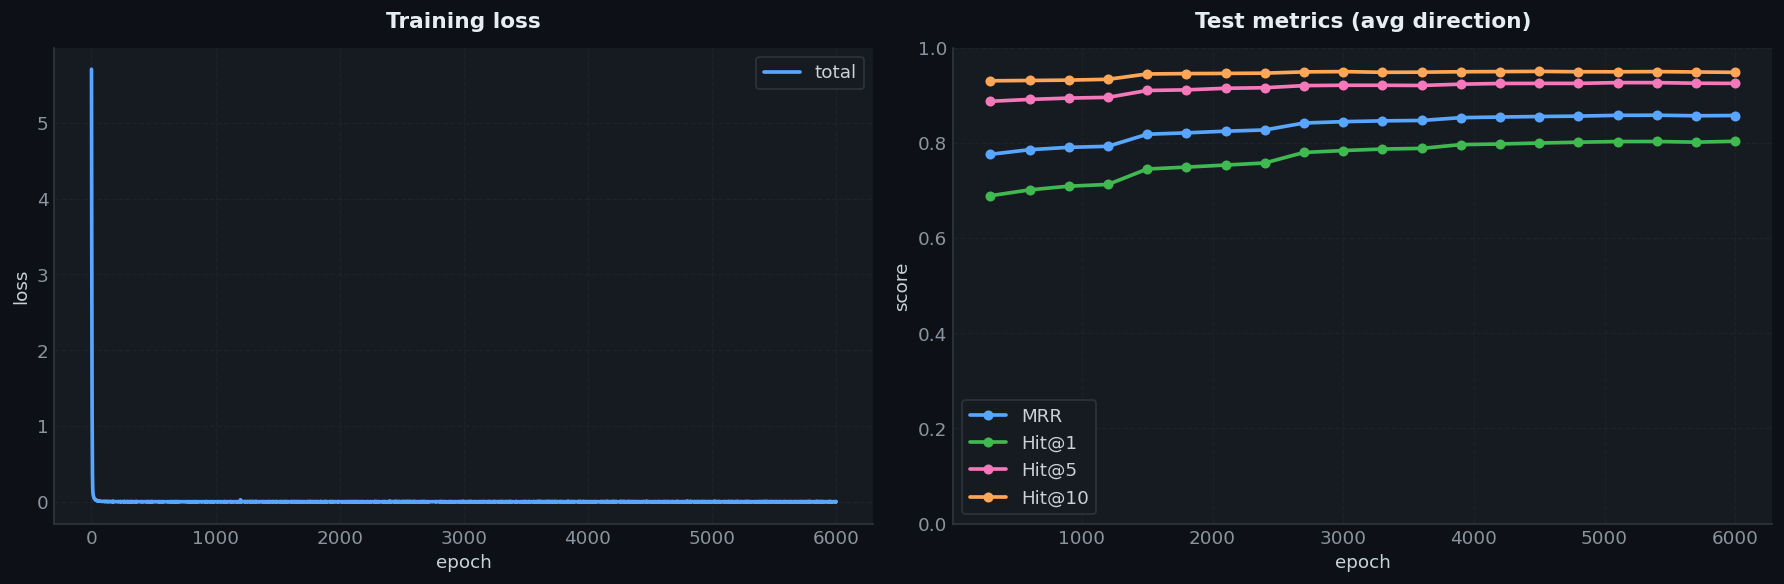

Meilleur MRR = 0.8580 a l'epoque 5400


In [38]:
loss_df = pd.read_csv(run_dir / cfg.logging.loss_csv)
met_df  = pd.read_csv(run_dir / cfg.logging.metrics_csv)
display(met_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss_curves(history["loss_hist"], ax=axes[0], keys=("loss",))
plot_metric_curves(history["metric_hist"], ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best MRR = {history['best_mrr']:.4f} at epoch {history['best_epoch']}")

---
## 8. Final evaluation and qualitative analysis

In [39]:
ckpt = torch.load(run_dir / "model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info(f"Best checkpoint reloaded (epoch {ckpt['epoch']}).")
with torch.no_grad():
    model.eval()
    z = model()
res = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                         metric=cfg.eval.metric, csls_k=cfg.eval.get("csls_k", 0),
                         chunk=cfg.eval.eval_chunk, direction="both")
print(format_metrics(res))

02:00:22 | INFO    | Meilleur checkpoint recharge (epoque 5400).
[l2r] MRR=0.8576 Hit@1=0.8024 Hit@5=0.9253 Hit@10=0.9489 MR=16.3 | [r2l] MRR=0.8584 Hit@1=0.8031 Hit@5=0.9274 Hit@10=0.9502 MR=14.9 | [avg] MRR=0.8580 Hit@1=0.8028 Hit@5=0.9264 Hit@10=0.9495 MR=15.6


/tmp/ipykernel_309199/1894539807.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(run_dir / "model_best.pt", map_location=device)


In [40]:
with torch.no_grad():
    zl = F.normalize(z[test_left], dim=-1); zr = F.normalize(z[test_right], dim=-1)
    top = (zl @ zr.t()).topk(3, dim=1).indices.cpu().numpy()
rows = []
for i in range(10):
    status = "hit@1" if top[i][0] == i else ("top-3" if i in top[i] else "miss")
    rows.append({"source (KG1)": data.ent_uri[int(test_left[i])].split("/")[-1],
                 "or (KG2)": data.ent_uri[int(test_right[i])].split("/")[-1],
                 "top-1": data.ent_uri[int(test_right[top[i][0]])].split("/")[-1],
                 "top-2": data.ent_uri[int(test_right[top[i][1]])].split("/")[-1],
                 "top-3": data.ent_uri[int(test_right[top[i][2]])].split("/")[-1],
                 "statut": status})
pd.DataFrame(rows)

,source (KG1),or (KG2),top-1,top-2,top-3,statut
0,阿卜杜拉·居尔,Abdullah_Gül,Abdullah_Gül,Bülent_Ecevit,Recep_Tayyip_Erdoğan,hit@1
1,金大中,Kim_Dae-jung,Kim_Dae-jung,Kim_Young-sam,Lee_Myung-bak,hit@1
2,民族陣線_(法國),National_Front_(France),National_Front_(France),Left_Front_(France),The_Republicans_(France),hit@1
3,香港丁組足球聯賽,Hong_Kong_Fourth_Division_League,Hong_Kong_Fourth_Division_League,Hong_Kong_Second_Division_League,Hong_Kong_Third_A_Division_League,hit@1
4,松山區_(臺灣),"Songshan_District,_Taipei",Swiss_Federal_Council,United_Nations,President_of_Mexico,miss
5,恩斯特·金恩,Ernest_King,Ernest_King,Chester_W._Nimitz,Raymond_A._Spruance,hit@1
6,哥連泰斯保利斯塔體育會,Sport_Club_Corinthians_Paulista,Sport_Club_Corinthians_Paulista,Figueirense_FC,Sport_Club_Internacional,hit@1
7,符騰堡王國,Kingdom_of_Württemberg,Kingdom_of_Württemberg,Kingdom_of_Prussia,Weimar_Republic,hit@1
8,IBooks,IBooks,IBooks,ITunes_Store,Wallet_(application),hit@1
9,约阿希姆·高克,Joachim_Gauck,Joachim_Gauck,Horst_Köhler,Angela_Merkel,hit@1


---
## 9. Saved artefacts

In [41]:
print("Run dir :", run_dir, "\n")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<22} {p.stat().st_size/1024:8.1f} KB")

Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/rrea_zh_en_0_3_20260602-014954 

  config_used.yaml            1.0 KB
  embeddings.pt           91313.7 KB
  loss.csv                  160.6 KB
  loss_curve.png             26.3 KB
  metrics.csv                 2.0 KB
  metrics_curve.png          47.8 KB
  model.pt                37490.1 KB
  model_best.pt           37490.8 KB
  training.txt                8.4 KB


---
## 10. Comparison with the paper

,Hit@1,Hit@10,MRR
modele,,,
RREA (papier semi),0.8010,0.9230,0.846
Ce notebook,0.8028,0.9495,0.858


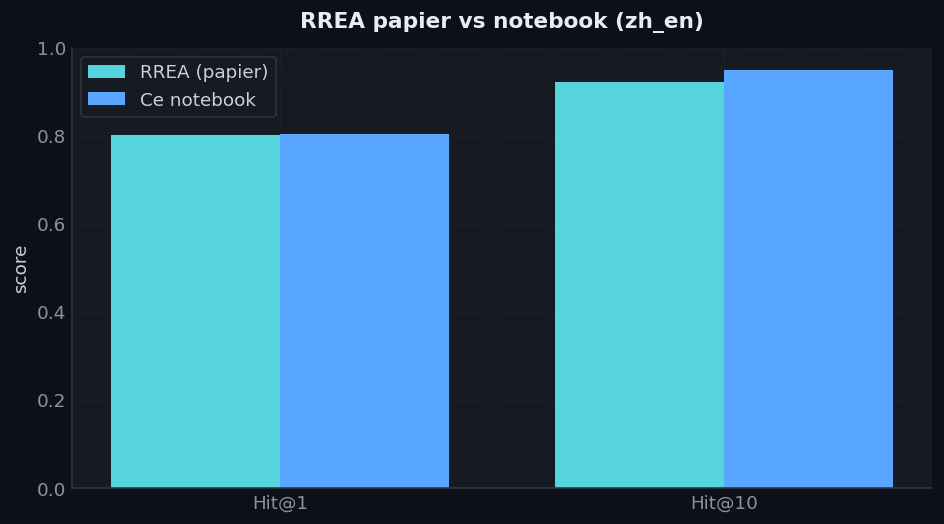

In [42]:
res_avg = res.get("avg", res.get("l2r"))
summary_df = pd.DataFrame([
    {"model": "RREA (paper semi)", "Hit@1": 0.801, "Hit@10": 0.923, "MRR": 0.846},
    {"model": "This notebook",          "Hit@1": res_avg["Hit@1"], "Hit@10": res_avg["Hit@10"], "MRR": res_avg["MRR"]},
]).set_index("model")
display(summary_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
names = ["Hit@1", "Hit@10"]; x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, [0.801, 0.923], w, label="RREA (paper)", color=CYCLE[5])
ax.bar(x + w/2, [res_avg["Hit@1"], res_avg["Hit@10"]], w, label="This notebook", color=CYCLE[0])
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1)
style_axes(ax, f"RREA paper vs notebook ({cfg.data.lang})", None, "score"); ax.legend()
plt.tight_layout(); plt.show()